In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cellphonedb.src.core.methods import cpdb_analysis_method

In [2]:
cpdb_analysis_method.call(
    cpdb_file_path = '../data/v5.0.0/cellphonedb.zip',
    meta_file_path = '../data/meta.tsv',
    counts_file_path = '../data/counts.tsv',
    counts_data = 'gene_name',
    score_interactions = True,
    output_path = '../interaction_result/out_cpdb'
)

[ ][CORE][18/04/25-14:55:54][INFO] [Non Statistical Method] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
../data/counts.tsv
../data/meta.tsv
[ ][CORE][18/04/25-14:55:56][INFO] Running Basic Analysis
[ ][CORE][18/04/25-14:55:56][INFO] Building results
[ ][CORE][18/04/25-14:55:56][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 10/10 [00:00<00:00, 493.80it/s]

[ ][CORE][18/04/25-14:55:56][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 10/10 [00:00<00:00, 1608.49it/s]

[ ][CORE][18/04/25-14:55:56][INFO] Scoring interactions: Calculating scores for all interactions and cell types..



/opt/anaconda3/envs/py310/lib/python3.10/site-packages/cellphonedb/utils/scoring_utils.py:138: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matrix[index_name].replace(to_replace=id2name, inplace=True)
100%|██████████| 100/100 [00:11<00:00,  8.84it/s]


Saved means_result to ../interaction_result/out_cpdb/simple_analysis_means_result_04_18_2025_145608.txt
Saved deconvoluted to ../interaction_result/out_cpdb/simple_analysis_deconvoluted_04_18_2025_145608.txt
Saved deconvoluted_percents to ../interaction_result/out_cpdb/simple_analysis_deconvoluted_percents_04_18_2025_145608.txt
Saved interaction_scores to ../interaction_result/out_cpdb/simple_analysis_interaction_scores_04_18_2025_145608.txt


{'means_result':      id_cp_interaction               interacting_pair      partner_a  \
 0      CPI-SC0A2DB962D     CDH1_integrin_a2b1_complex  simple:P12830   
 1      CPI-SC0B5CEA47D  COL10A1_integrin_a2b1_complex  simple:Q03692   
 2      CPI-SC0C8B7BCBB  COL11A1_integrin_a2b1_complex  simple:P12107   
 3      CPI-SC0D3C12C3F  COL11A2_integrin_a2b1_complex  simple:P13942   
 4      CPI-SC0B86B7CED  COL12A1_integrin_a2b1_complex  simple:Q99715   
 ...                ...                            ...            ...   
 2906   CPI-SS07D508428                  SIGLEC15_CD44  simple:Q6ZMC9   
 2907   CPI-SS02A170A99                    SPN_SIGLEC1  simple:P16150   
 2908   CPI-SS0DC2DD9D7                       THPO_MPL  simple:P40225   
 2909   CPI-SS00F69C501                       TRH_TRHR  simple:P20396   
 2910   CPI-SS0AB1A3A6D                   CD177_PECAM1  simple:Q8N6Q3   
 
                           partner_b    gene_a   gene_b  secreted  receptor_a  \
 0     complex:integrin_a

In [6]:
means_path = "../interaction_result/out_cpdb/simple_analysis_interaction_scores_04_18_2025_145608.txt"
means_df = pd.read_csv(means_path, sep="\t")
means_df.head()

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,pDC|B cell,pDC|Endothelial,pDC|Epithelial,pDC|Fibroblast,pDC|Macrophage,pDC|Mast cell,pDC|Melanocyte,pDC|T cell,pDC|cDC,pDC|pDC
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.000,0.000
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,...,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.000,0.000
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.000,0.000
3,CPI-SC0D3C12C3F,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,True,False,False,curated,...,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.000,0.000
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.0,8.841,18.986,0.0,0.0,16.127,8.402,0.0,18.754,17.615


In [14]:
interaction_cols = [col for col in means_df.columns if "|" in col]
means_df = means_df[means_df["interacting_pair"].notna()]
means_df["mean_score"] = means_df[interaction_cols].mean(axis=1)
top20_df = means_df.sort_values("mean_score", ascending=False).head(20)

In [15]:
heatmap_data = top20_df.set_index("interacting_pair")[interaction_cols]

keywords = ["TP53", "EGFR", "PDCD1", "CD274",
          "CEACAM5", "IFNG", "MMP2", "SOX2", "ALDH1A1"]
filtered_df = means_df[means_df["interacting_pair"].str.contains("|".join(keywords), case=False)]

top20_df[["interacting_pair"] + interaction_cols].to_csv("../data/top20_interactions.tsv", sep="\t", index=False)
filtered_df.to_csv("../data/filtered_keywords.tsv", sep="\t", index=False)

In [16]:
top20_df.set_index("interacting_pair", inplace=True)
top20_df = top20_df.select_dtypes(include=["number"])

top20_df.columns = [col.replace("|", " → ") for col in top20_df.columns]

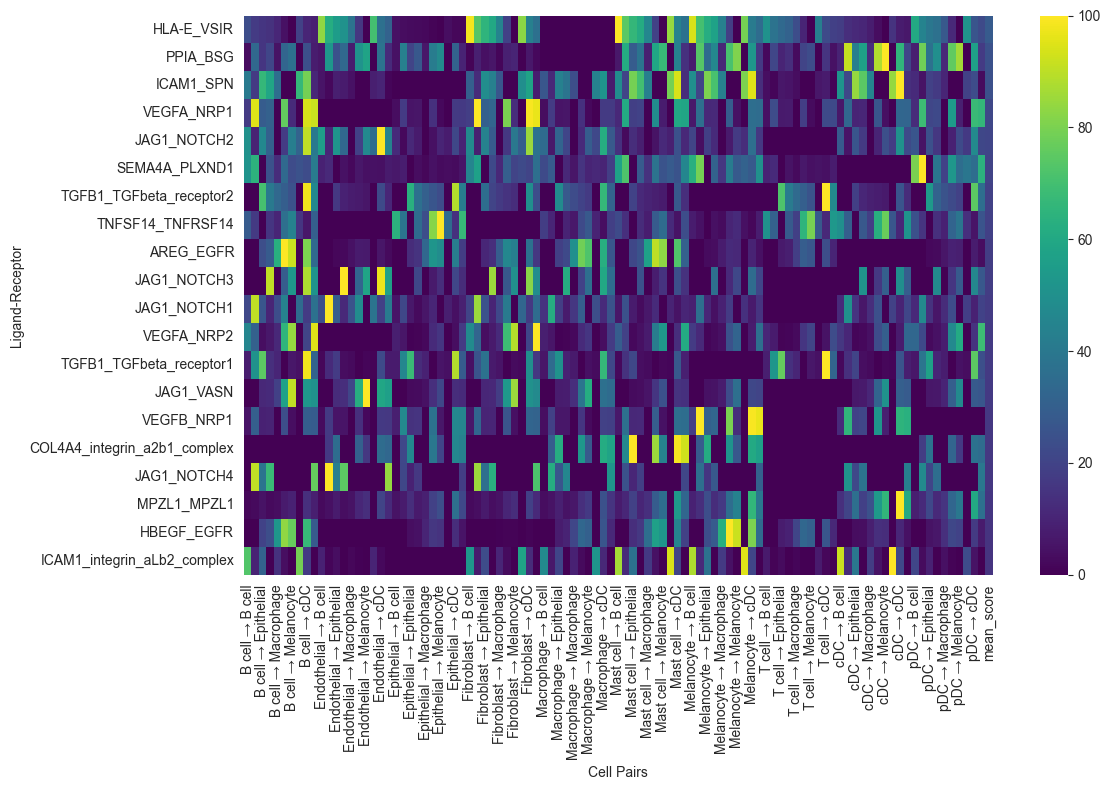

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(top20_df, cmap="viridis", annot=False)
plt.xlabel("Cell Pairs")
plt.ylabel("Ligand-Receptor")
plt.tight_layout()
plt.savefig('../figures/interactions.png', dpi=300)